In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = '/content/drive/MyDrive/v32/windows.zip'
extract_path = '/content/data/windows'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted:")
!find /content/data/windows -name "*.npy" | wc -l

Mounted at /content/drive
Extracted:
3613


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [4]:
CFG = {
    "windows_dir":    "/content/data/windows",
    "manifest_path":  "/content/data/windows/windows_manifest.csv",
    "checkpoint_dir": "/content/drive/MyDrive/v32",
    "architecture":   "convlstm",   # "convlstm" or "3dcnn"
    "window_size":    16,
    "feat_h":         32,
    "feat_w":         32,
    "in_channels":    2,
    "hidden_dim":     64,
    "num_classes":    2,
    "batch_size":     32,
    "epochs":         50,
    "lr":             3e-4,
    "weight_decay":   1e-4,
    "patience":       10,
    "val_split":      0.2,
    "seed":           42,
}
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

In [5]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(CFG["manifest_path"])

# ShanghaiTech: anomaly only in test split — merge all for classifier training
all_df = df.reset_index(drop=True)

print(f"Total windows: {len(all_df)}")
print(f"Label dist: {all_df['label'].value_counts().to_dict()}")

train_idx, temp_idx = train_test_split(
    range(len(all_df)),
    test_size=0.3,
    stratify=all_df["label"],
    random_state=CFG["seed"]
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=all_df.iloc[temp_idx]["label"],
    random_state=CFG["seed"]
)

class WindowDataset(Dataset):
    def __init__(self, df, windows_dir):
        self.df = df.reset_index(drop=True)
        self.windows_dir = Path(windows_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        p = Path(row["window_path"])
        parts = p.parts
        for i, part in enumerate(parts):
            if part in ("train", "test"):
                rel = Path(*parts[i:])
                break
        full_path = self.windows_dir / rel
        window = np.load(str(full_path))
        label = int(row["label"])
        return torch.from_numpy(window).float(), torch.tensor(label, dtype=torch.long)


train_ds = WindowDataset(all_df.iloc[train_idx], CFG["windows_dir"])
val_ds   = WindowDataset(all_df.iloc[val_idx],   CFG["windows_dir"])
test_ds  = WindowDataset(all_df.iloc[test_idx],  CFG["windows_dir"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False, num_workers=2)

print(f"\nTrain: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"Train dist: {all_df.iloc[train_idx]['label'].value_counts().to_dict()}")
print(f"Val   dist: {all_df.iloc[val_idx]['label'].value_counts().to_dict()}")
print(f"Test  dist: {all_df.iloc[test_idx]['label'].value_counts().to_dict()}")

Total windows: 4376
Label dist: {0: 3472, 1: 904}

Train: 3063  Val: 656  Test: 657
Train dist: {0: 2430, 1: 633}
Val   dist: {0: 521, 1: 135}
Test  dist: {0: 521, 1: 136}


In [6]:
# --- ConvLSTM Cell ---
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_ch = hidden_ch
        self.gates = nn.Conv2d(in_ch + hidden_ch, 4 * hidden_ch, kernel_size, padding=pad)

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.gates(combined)
        i, f, g, o = gates.chunk(4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c


class ConvLSTMClassifier(nn.Module):
    def __init__(self, in_ch, hidden_dim, num_classes, feat_h, feat_w):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.feat_h = feat_h
        self.feat_w = feat_w
        self.cell = ConvLSTMCell(in_ch, hidden_dim)
        pool_h = feat_h // 4
        pool_w = feat_w // 4
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((pool_h, pool_w)),
            nn.Flatten(),
            nn.Linear(hidden_dim * pool_h * pool_w, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
        return self.classifier(h)


# --- Lightweight 3D CNN ---
class CNN3DClassifier(nn.Module):
    def __init__(self, in_ch, num_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(in_ch, 32, kernel_size=(3,3,3), padding=1), nn.ReLU(inplace=True),
            nn.MaxPool3d((2,2,2)),
            nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=1), nn.ReLU(inplace=True),
            nn.MaxPool3d((2,2,2)),
            nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1,1,1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: (B, T, C, H, W) -> (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        return self.classifier(self.encoder(x))


def build_model(cfg):
    if cfg["architecture"] == "convlstm":
        return ConvLSTMClassifier(cfg["in_channels"], cfg["hidden_dim"],
                                  cfg["num_classes"], cfg["feat_h"], cfg["feat_w"])
    else:
        return CNN3DClassifier(cfg["in_channels"], cfg["num_classes"])

model = build_model(CFG).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model : {CFG['architecture']}")
print(f"Params: {total_params:,}")

Model : convlstm
Params: 676,994


In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / total, correct / total, auc


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])

best_auc = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}
ckpt_path = f"{CFG['checkpoint_dir']}/best_model.pth"

for epoch in range(1, CFG["epochs"] + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_auc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_auc"].append(vl_auc)

    print(f"Epoch {epoch:03d} | "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} vl_auc={vl_auc:.4f}")

    if vl_auc > best_auc:
        best_auc = vl_auc
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_auc": vl_auc,
            "val_acc": vl_acc,
            "cfg": CFG,
        }, ckpt_path)
        print(f"  ✓ Best checkpoint saved (AUC={best_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= CFG["patience"]:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nTraining complete. Best Val AUC: {best_auc:.4f}")

Epoch 001 | tr_loss=0.5236 tr_acc=0.7800 | vl_loss=0.4981 vl_acc=0.7942 vl_auc=0.5952
  ✓ Best checkpoint saved (AUC=0.5952)
Epoch 002 | tr_loss=0.4794 tr_acc=0.7950 | vl_loss=0.4448 vl_acc=0.7973 vl_auc=0.7528
  ✓ Best checkpoint saved (AUC=0.7528)
Epoch 003 | tr_loss=0.4506 tr_acc=0.7979 | vl_loss=0.4479 vl_acc=0.7957 vl_auc=0.7631
  ✓ Best checkpoint saved (AUC=0.7631)
Epoch 004 | tr_loss=0.4338 tr_acc=0.8051 | vl_loss=0.4151 vl_acc=0.8171 vl_auc=0.7871
  ✓ Best checkpoint saved (AUC=0.7871)
Epoch 005 | tr_loss=0.4006 tr_acc=0.8191 | vl_loss=0.3881 vl_acc=0.8186 vl_auc=0.8416
  ✓ Best checkpoint saved (AUC=0.8416)
Epoch 006 | tr_loss=0.3846 tr_acc=0.8253 | vl_loss=0.3649 vl_acc=0.8399 vl_auc=0.8523
  ✓ Best checkpoint saved (AUC=0.8523)
Epoch 007 | tr_loss=0.3591 tr_acc=0.8384 | vl_loss=0.3467 vl_acc=0.8430 vl_auc=0.8693
  ✓ Best checkpoint saved (AUC=0.8693)
Epoch 008 | tr_loss=0.3319 tr_acc=0.8544 | vl_loss=0.3369 vl_acc=0.8384 vl_auc=0.8847
  ✓ Best checkpoint saved (AUC=0.8847)


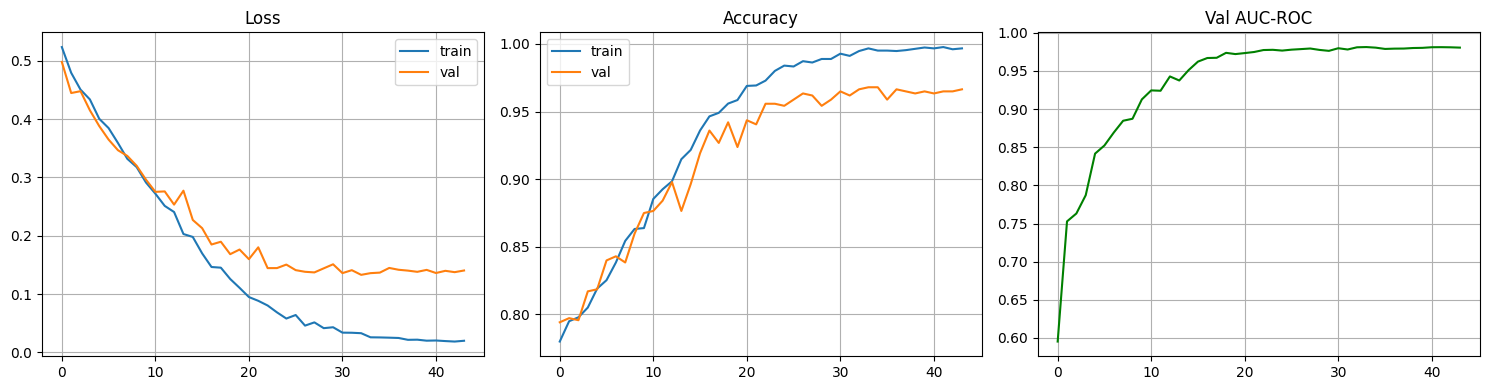

Curves saved to Drive


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history["val_auc"], color="green")
axes[2].set_title("Val AUC-ROC"); axes[2].grid(True)

plt.tight_layout()
plt.savefig(f"{CFG['checkpoint_dir']}/training_curves.png", dpi=120)
plt.show()
print("Curves saved to Drive")

In [10]:
# Load best checkpoint
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best checkpoint — epoch {ckpt['epoch']}, val AUC {ckpt['val_auc']:.4f}")

# Test evaluation
te_loss, te_acc, te_auc = eval_epoch(model, test_loader, criterion)
print(f"\nTest Loss : {te_loss:.4f}")
print(f"Test Acc  : {te_acc:.4f}")
print(f"Test AUC  : {te_auc:.4f}")

# Full report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["normal", "anomaly"]))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Loaded best checkpoint — epoch 34, val AUC 0.9813

Test Loss : 0.2163
Test Acc  : 0.9422
Test AUC  : 0.9648

Classification Report:
              precision    recall  f1-score   support

      normal       0.95      0.98      0.96       521
     anomaly       0.90      0.82      0.85       136

    accuracy                           0.94       657
   macro avg       0.92      0.90      0.91       657
weighted avg       0.94      0.94      0.94       657

Confusion Matrix:
[[508  13]
 [ 25 111]]


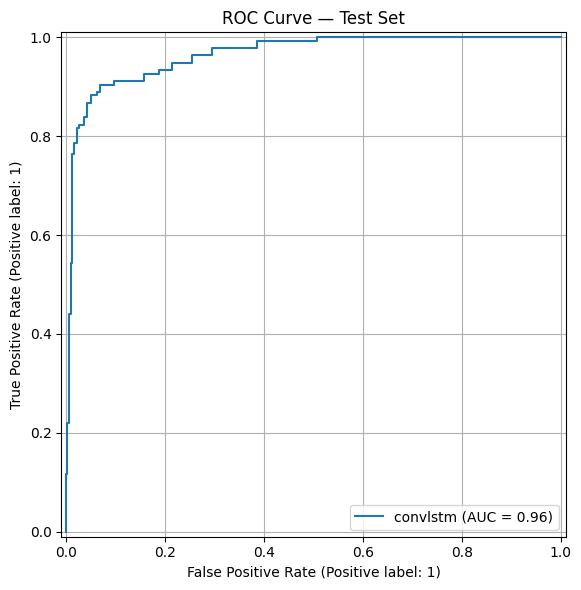

ROC curve saved to Drive


In [11]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        probs = torch.softmax(model(x), dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y.numpy())

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(all_labels, all_probs, ax=ax, name=CFG["architecture"])
ax.set_title("ROC Curve — Test Set")
ax.grid(True)
plt.tight_layout()
plt.savefig(f"{CFG['checkpoint_dir']}/roc_curve.png", dpi=120)
plt.show()
print("ROC curve saved to Drive")

In [12]:
import torch
import numpy as np

# Load with weights_only=False
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# Re-save cleanly — only save what's needed
torch.save({
    "epoch": int(ckpt["epoch"]),
    "model_state_dict": {k: v for k, v in ckpt["model_state_dict"].items()},
    "val_auc": float(ckpt["val_auc"]),
    "val_acc": float(ckpt["val_acc"]),
}, "/content/drive/MyDrive/v32/best_model_clean.pth")

print("Saved clean checkpoint")

Saved clean checkpoint
